# Bootcamp Python - PY4
## Modulo 2: Machine Learning Avanzado y Feature Engineering
### Sesion 2: Reduccion de Dimensionalidad y K-Means

Segmentacion de perfiles basada en algoritmos no supervisados.

---

### Que hicimos en la Sesion 1

- Exploramos el dataset `CC_GENERAL` (nulos, distribuciones, outliers, correlaciones).
- Construimos un Pipeline de Scikit-learn con `SimpleImputer` (mediana) y `StandardScaler`.

### Que vamos a hacer hoy

1. Reducir la dimensionalidad de los datos con **PCA** para poder visualizarlos en 2D.
2. Entrenar nuestro primer algoritmo de clustering: **K-Means**.
3. Justificar el numero de clusters (K) usando el **Metodo del Codo** y el **Coeficiente de
   Silueta**.
4. Visualizar los clusters resultantes sobre las componentes principales.

### Paso 0: Configuracion inicial y recarga de datos

Como estamos en una notebook nueva, necesitamos volver a cargar el dataset y reconstruir el
pipeline de preprocesamiento que armamos en la Sesion 1. Esto es una practica comun: cada
notebook debe poder ejecutarse de principio a fin sin depender de otra notebook abierta en
paralelo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("white")
pd.set_option("display.max_columns", None)


In [ ]:
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/"

df = pd.read_csv(BASE_URL + "CC_GENERAL.csv")
df.columns = df.columns.str.capitalize()

features = df.drop(columns=["Cust_id"])
customer_ids = df["Cust_id"]

pipeline_preprocesamiento = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

features_procesadas = pipeline_preprocesamiento.fit_transform(features)
df_procesado = pd.DataFrame(features_procesadas, columns=features.columns)

df_procesado.head()


,Balance,Balance_frequency,Purchases,Oneoff_purchases,Installments_purchases,Cash_advance,Purchases_frequency,Oneoff_purchases_frequency,Purchases_installments_frequency,Cash_advance_frequency,Cash_advance_trx,Purchases_trx,Credit_limit,Payments,Minimum_payments,Prc_full_payment,Tenure
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


### Por que reducir dimensionalidad

Nuestro dataset tiene 17 features numericas. No podemos graficar en 17 dimensiones, pero
necesitamos una forma de **visualizar** si existen agrupaciones naturales en los datos antes
(y despues) de aplicar un algoritmo de clustering.

**PCA (Principal Component Analysis)** crea nuevas variables (componentes principales) que son
combinaciones lineales de las variables originales, ordenadas segun cuanta varianza (informacion)
explican. Las primeras 2 o 3 componentes suelen capturar gran parte de la informacion relevante,
lo que nos permite graficar en 2D o 3D sin perder demasiado.

Nota: en el contenido teorico tambien se menciona **UMAP** como alternativa. UMAP suele preservar
mejor la estructura no lineal de los datos, pero PCA es mas simple de interpretar (sabemos que
cada componente es una combinacion lineal de las variables originales) y es un buen punto de
partida.

### Paso 1: Elegir el numero de componentes

Antes de fijar un numero de componentes, es buena practica mirar cuanta varianza explica cada
una. Vamos a ajustar un PCA con todas las componentes posibles y graficar la **varianza explicada
acumulada**.

In [ ]:
# PCA solo se pueder aplicar a un dataset numerico! No podemos tener variable de categoria o string
df_procesado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Balance                           8950 non-null   float64
 1   Balance_frequency                 8950 non-null   float64
 2   Purchases                         8950 non-null   float64
 3   Oneoff_purchases                  8950 non-null   float64
 4   Installments_purchases            8950 non-null   float64
 5   Cash_advance                      8950 non-null   float64
 6   Purchases_frequency               8950 non-null   float64
 7   Oneoff_purchases_frequency        8950 non-null   float64
 8   Purchases_installments_frequency  8950 non-null   float64
 9   Cash_advance_frequency            8950 non-null   float64
 10  Cash_advance_trx                  8950 non-null   float64
 11  Purchases_trx                     8950 non-null   float64
 12  Credit

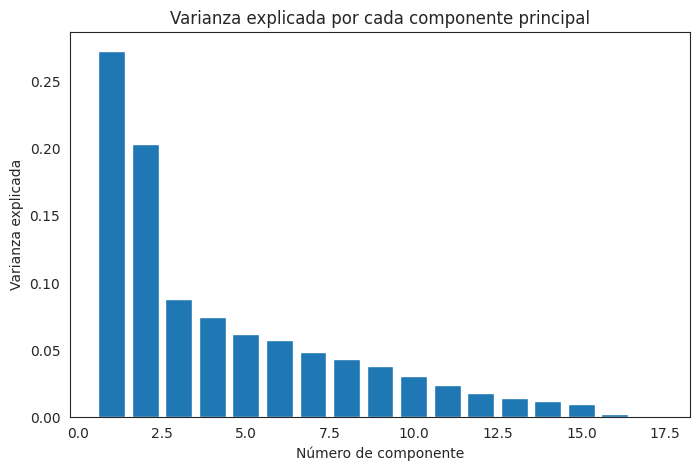

In [ ]:
pca_completo = PCA() # crea un modelo PCA

pca_completo.fit(df_procesado) # fit el PCA a los datos para calcular la varianza explicada por cada componente

varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_) # calcula la varianza explicada acumulada a medida que se agregan componentes


# grafica la varianza explicada individual por cada componente
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(pca_completo.explained_variance_ratio_) + 1),
    pca_completo.explained_variance_ratio_
)

plt.xlabel("Número de componente")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada por cada componente principal")

plt.show()


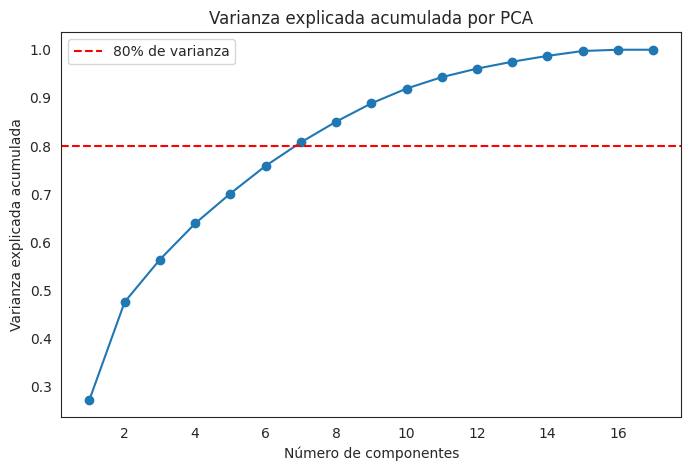

In [ ]:
# grafica la varianza acumulada en función del número de componentes principales
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")

# línea de referencia para identificar cuántos componentes explican al menos el 80% de la varianza
plt.axhline(y=0.80, color="red", linestyle="--", label="80% de varianza")

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por PCA")
plt.legend()
plt.show()

Cuantas componentes se necesitan para explicar
alrededor del 80% de la varianza? Ese numero nos podria servir si quisieramos usar PCA para
modelar (reducir ruido antes del clustering). Pero para **visualizar**, siempre nos quedamos con
2 (o 3) componentes, aunque expliquen un porcentaje menor de la varianza total.

### Paso 2: PCA a 2 componentes para visualizacion

Ahora ajustamos un PCA que se quede solo con **2 componentes principales**. Vamos a graficar los
datos en ese plano para ver si a simple vista se distinguen agrupaciones, antes de aplicar
cualquier algoritmo de clustering.

Varianza explicada por PC1 y PC2: [0.273 0.203]
Varianza explicada total (PC1 + PC2): 0.476


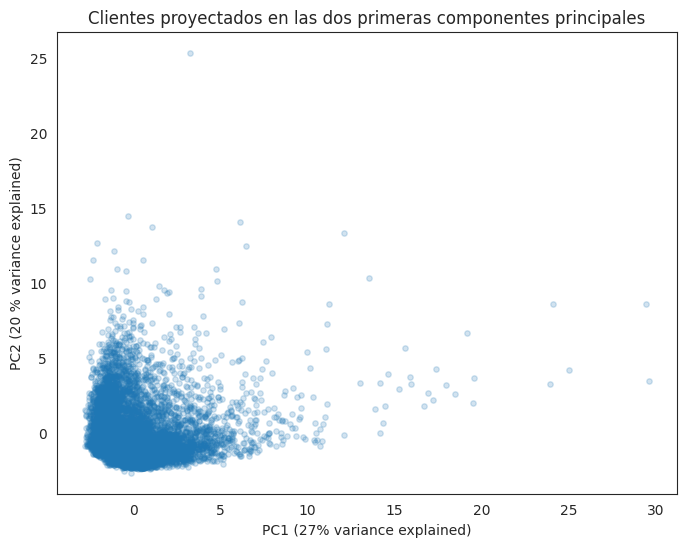

In [ ]:
# transforma los datos usando el PCA ya entrenado
componentes = pca_completo.transform(df_procesado)

# selecciona únicamente las dos primeras componentes principales
df_pca = pd.DataFrame(
    componentes[:, :3],
    columns=["PC1", "PC2", "PC3"]
)

# muestra la varianza explicada por las dos primeras componentes
print("Varianza explicada por PC1 y PC2:",
      np.round(pca_completo.explained_variance_ratio_[:2], 3))

print("Varianza explicada total (PC1 + PC2):",
    np.round(pca_completo.explained_variance_ratio_[:2].sum(), 3))

# visualización en 2 dimensiones
plt.figure(figsize=(8, 6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.2, s=15)

plt.xlabel("PC1 (27% variance explained)")
plt.ylabel("PC2 (20 % variance explained)")
plt.title("Clientes proyectados en las dos primeras componentes principales")
plt.show()

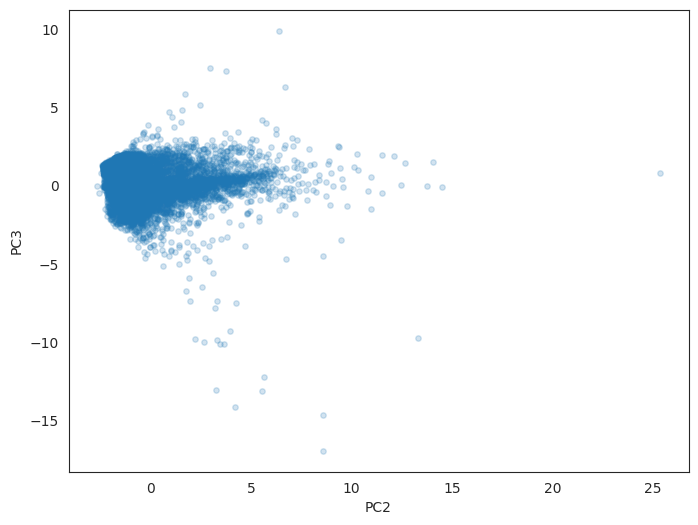

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_pca["PC2"],
    df_pca["PC3"],
    alpha=0.2,
    s=15
)
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.show()

### ¿Qué información transporta los Principal Components?  

Los **loadings** indican cuánto contribuye cada variable original a cada componente principal valores altos (positivos o negativos) = mayor influencia en ese componente

In [ ]:
## el objeto 'pca_completo.components_' contiene los loading (cada linea tiene un loading para cada features)
pd.DataFrame(pca_completo.components_)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.101735,0.120490,0.411562,0.346334,0.336761,-0.022810,0.321232,0.294493,0.274494,-0.088582,-0.048136,0.390599,0.211916,0.266482,0.063269,0.131833,0.081086
1,0.403819,0.131344,0.040025,0.061918,-0.019175,0.439027,-0.191148,-0.018561,-0.178869,0.434121,0.419644,-0.020168,0.238028,0.256716,0.169066,-0.190065,-0.004255
2,0.161632,0.422995,-0.257474,-0.390899,0.109268,0.023128,0.371394,-0.115565,0.469579,0.104709,0.110345,0.075929,-0.100682,-0.277359,0.234517,-0.126477,0.067989
3,0.279316,0.155762,0.041621,0.085079,-0.057915,-0.256596,-0.194564,0.034279,-0.225288,-0.264628,-0.328386,-0.020794,0.131533,-0.112148,0.392560,-0.419574,0.437548
4,-0.051022,0.476836,-0.027887,0.160839,-0.361402,-0.097560,0.099667,0.540330,-0.176996,0.145160,0.083884,0.036237,-0.086303,-0.200851,-0.415045,-0.143363,0.001838
5,-0.042752,-0.022045,-0.180453,-0.179984,-0.096003,0.145018,0.046867,0.003524,0.048051,-0.058183,0.064631,-0.100930,0.320143,0.116040,-0.290166,0.352643,0.745456
6,0.254182,-0.100801,-0.200220,-0.120685,-0.251771,0.048730,0.150818,0.281432,-0.038003,-0.144220,-0.198738,-0.109343,0.557414,-0.156826,0.200462,0.300495,-0.404204
7,-0.170294,0.283496,0.026055,0.126974,-0.171696,-0.022416,-0.048180,0.081080,-0.160940,0.045503,0.101343,-0.102120,-0.340911,0.087234,0.570162,0.572924,0.095524
8,0.128514,0.616254,0.104777,0.014005,0.222023,-0.049427,-0.218490,-0.400377,-0.067279,-0.087426,-0.255072,-0.198937,0.158411,0.090121,-0.293557,0.232958,-0.205659
9,-0.031174,0.081581,-0.051163,0.175468,-0.443269,0.359217,0.250743,-0.109797,0.252539,-0.285996,-0.218660,-0.248585,-0.158312,0.466062,0.004642,-0.241186,-0.053565


In [ ]:
loadings = pd.DataFrame(
    pca_completo.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_completo.n_components_)],
    index=df_procesado.columns
)

# mostramos las variables con mayor contribución absoluta a PC1 y PC2
for pc in ["PC1", "PC2"]:

    print(f"\nVariables con mayor influencia en {pc}")

    display(
    loadings[pc]
    .loc[loadings[pc].abs().sort_values(ascending=False).head(5).index]
    # selecciona las 5 variables con mayor loading absoluto,
    # pero mantiene el valor original (positivo o negativo)
)


Variables con mayor influencia en PC1


,PC1
Purchases,0.411562
Purchases_trx,0.390599
Oneoff_purchases,0.346334
Installments_purchases,0.336761
Purchases_frequency,0.321232



Variables con mayor influencia en PC2


,PC2
Cash_advance,0.439027
Cash_advance_frequency,0.434121
Cash_advance_trx,0.419644
Balance,0.403819
Payments,0.256716


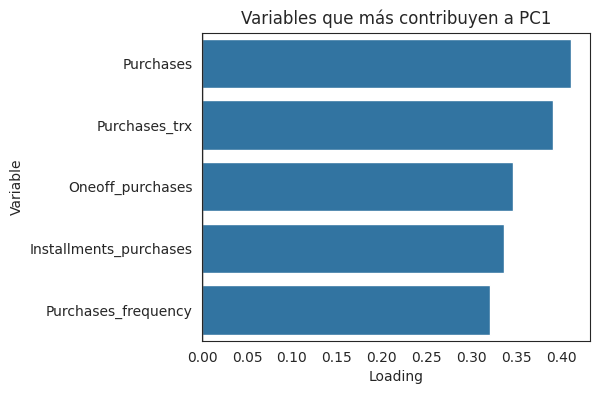

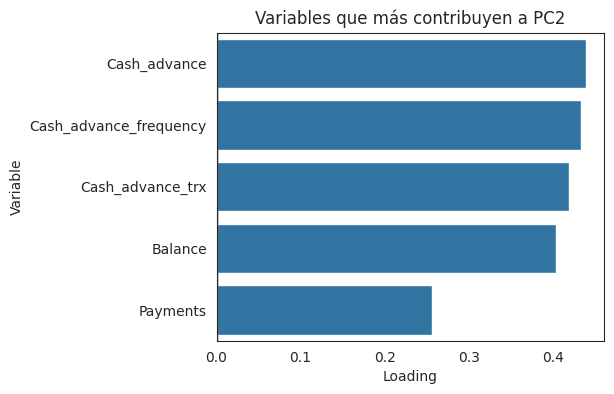

In [ ]:
# Top 10 variables que más contribuyen a PC1
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(5).index

plt.figure(figsize=(5, 4))
sns.barplot(
    x=loadings.loc[top_pc1, "PC1"],
    y=top_pc1
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Loading")
plt.ylabel("Variable")
plt.title("Variables que más contribuyen a PC1")
plt.show()


# Top 10 variables que más contribuyen a PC2
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(5).index

plt.figure(figsize=(5, 4))
sns.barplot(
    x=loadings.loc[top_pc2, "PC2"],
    y=top_pc2
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Loading")
plt.ylabel("Variable")
plt.title("Variables que más contribuyen a PC2")
plt.show()

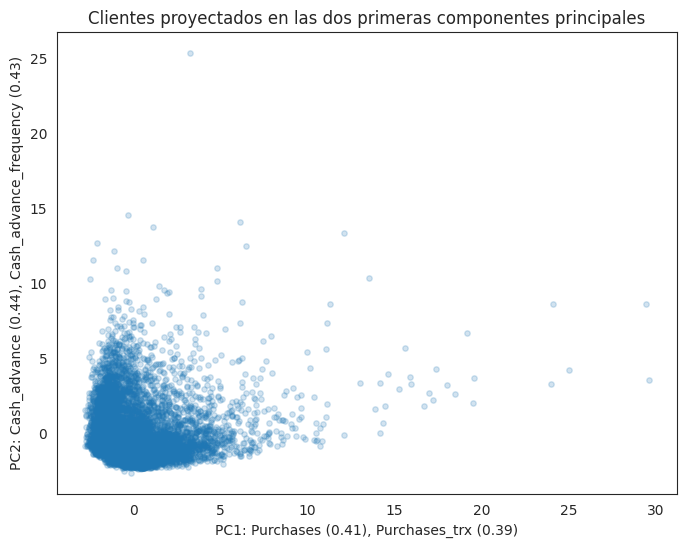

In [ ]:
## mostrar el plot del PC1 vs PC2 con los loadings como etiqueta de axis

# Obtener las 3 variables más importantes de cada componente
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(2).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(2).index

# Crear texto con variable + loading
label_pc1 = "PC1: " + ", ".join(
    [f"{var} ({loadings.loc[var, 'PC1']:.2f})" for var in top_pc1]
)

label_pc2 = "PC2: " + ", ".join(
    [f"{var} ({loadings.loc[var, 'PC2']:.2f})" for var in top_pc2]
)


plt.figure(figsize=(8, 6))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.2,
    s=15
)

plt.xlabel(label_pc1, fontsize=10)
plt.ylabel(label_pc2, fontsize=10)

plt.title("Clientes proyectados en las dos primeras componentes principales")

plt.show()

### K-Means: intuicion del algoritmo

K-Means agrupa los puntos en **K** clusters (K lo definimos nosotros) siguiendo esta idea:

1. Se eligen K centroides iniciales (al azar).
2. Cada punto se asigna al centroide mas cercano.
3. Cada centroide se recalcula como el promedio de los puntos asignados.
4. Se repiten los pasos 2 y 3 hasta que los centroides ya no cambian (o cambian muy poco).

--> Mira ese vídeo para hacerte una idea de cómo funciona el algoritmo. https://www.youtube.com/watch?v=R2e3Ls9H_fc


El problema central de K-Means es que **nosotros debemos elegir K de antemano**. Para justificar
esa eleccion usamos dos herramientas: el **Metodo del Codo** y el **Coeficiente de Silueta**.

### Paso 3: Metodo del Codo (Elbow Method)

La **inercia** de un modelo K-Means es la suma de las distancias al cuadrado entre cada punto y
su centroide asignado. A medida que aumentamos K, la inercia siempre baja (mas centroides,
puntos mas cerca de "su" centroide), pero llega un punto donde agregar mas clusters ya no
mejora mucho la inercia. Ese punto de quiebre ("codo") es un buen candidato para K.

Vamos a entrenar K-Means para varios valores de K (por ejemplo de 2 a 10) y graficar la inercia
en funcion de K.

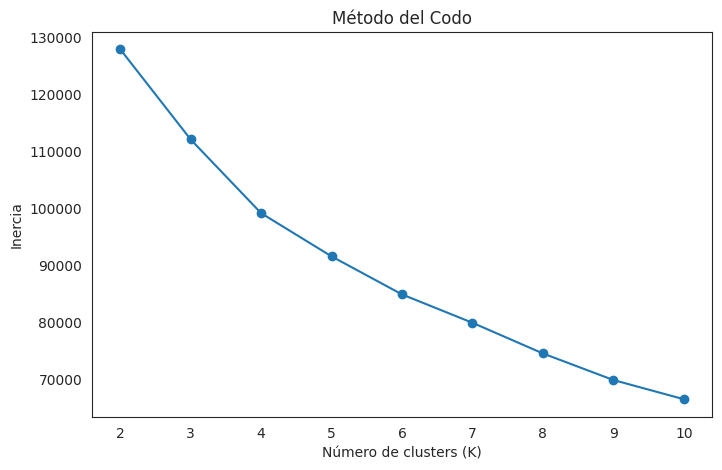

In [ ]:
valores_k = range(2, 11) # define diferentes valores de K (número de clusters) que se probarán

inercias = [] # lista donde se almacenará la inercia obtenida para cada valor de K

# entrena un modelo K-Means para cada cantidad de clusters y guarda su inercia
for k in valores_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10: ejecuta K-Means 10 veces con diferentes posiciones iniciales
    modelo_kmeans.fit(df_procesado)
    inercias.append(modelo_kmeans.inertia_) # la inercia mide qué tan compactos son los clusters (menor inercia = puntos más cerca de su centroide)

# grafica la evolución de la inercia al aumentar el número de clusters
plt.figure(figsize=(8, 5))
plt.plot(list(valores_k), inercias, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.show()

La inercia puede interpretarse como una medida de **qué tan compactos son los clusters**.

Un valor bajo de inercia significa que los clientes dentro de cada cluster están cerca de su centroide, mientras que una inercia alta indica grupos más dispersos.

Al aumentar K, los clusters se vuelven más pequeños y compactos, por lo que la inercia siempre disminuye. Sin embargo, llega un punto donde crear más clusters aporta muy poca mejora adicional. Ese punto de "codo" ayuda a elegir un número adecuado de clusters.

### Paso 4: Coeficiente de Silueta (Silhouette Score)

El Metodo del Codo es util pero a veces el "codo" no es tan claro visualmente. El **Coeficiente
de Silueta** nos da un numero (entre -1 y 1) que mide que tan bien separados y compactos estan
los clusters:

- Cercano a 1: los clusters estan bien separados y son compactos.
- Cercano a 0: los clusters se superponen.
- Negativo: puntos probablemente mal asignados.

Vamos a calcular el silhouette score para el mismo rango de K y graficarlo.

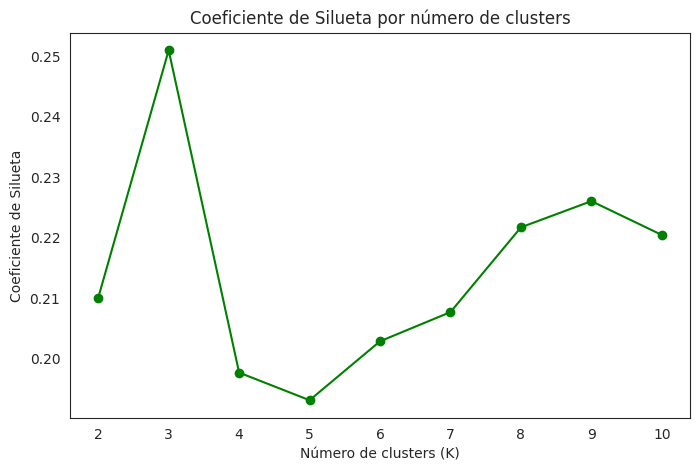

In [ ]:
silhouette_scores = [] # lista donde se almacenará el coeficiente de silueta para cada valor de K

# prueba diferentes cantidades de clusters
for k in valores_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # crea y entrena un modelo K-Means con K clusters

    etiquetas = modelo_kmeans.fit_predict(df_procesado) # obtiene el cluster asignado a cada observación después del entrenamiento

    score = silhouette_score(df_procesado, etiquetas) # calcula el coeficiente de silueta:

    silhouette_scores.append(score) # guarda el resultado para este valor de K



# grafica cómo cambia la calidad de los clusters según K
plt.figure(figsize=(8, 5))
plt.plot(list(valores_k), silhouette_scores, marker="o", color="green")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de Silueta")
plt.title("Coeficiente de Silueta por número de clusters")

plt.show()

El K que sugiere el Metodo del Codo coincide con el K
que sugiere el mejor Coeficiente de Silueta? Si no coinciden, cual eligen y por que?  
En un
proyecto real, la eleccion final tambien debe considerar si el numero de clusters resultante
tiene sentido para el negocio (por ejemplo, el equipo de marketing no puede manejar 10
estrategias distintas).  

  

#### Interpretación de negocio
- ¿Los 3 perfiles de clientes obtenidos son más fáciles de entender y utilizar para tomar decisiones?
- ¿El cuarto grupo representa un segmento de clientes con características realmente diferentes y con valor para el negocio?

### Paso 5: Entrenar el modelo final de K-Means

Con base en el analisis anterior, elegimos un valor de K y entrenamos el modelo final. Guardamos
las etiquetas de cluster en el DataFrame original para poder interpretarlas mas adelante.

In [ ]:
K_ELEGIDO = 4  # Actualiza este valor segun lo que concluyeron con el codo y la silueta

modelo_kmeans_final = KMeans( # crea el modelo K-Means final utilizando el número de clusters elegido previamente
    n_clusters=K_ELEGIDO,
    random_state=42,
    n_init=10
)

clusters_kmeans = modelo_kmeans_final.fit_predict(df_procesado) # entrena el modelo y asigna a cada observación el cluster correspondiente

# agrega la etiqueta de cluster al dataset original para analizar los grupos obtenidos
df["cluster_kmeans"] = clusters_kmeans

df_pca["cluster_kmeans"] = clusters_kmeans # agrega la misma información al dataset reducido por PCA para poder visualizar los clusters

# muestra la cantidad de clientes dentro de cada cluster
# permite verificar si los grupos están equilibrados o si existe algún cluster muy pequeño
df["cluster_kmeans"].value_counts().sort_index()

,count
cluster_kmeans,
0,3977
1,409
2,1197
3,3367


### Paso 6: Visualizar los clusters sobre las componentes principales

Ahora si coloreamos el mismo grafico de PC1 vs PC2 segun el cluster asignado por K-Means. Esto
nos permite ver visualmente que tan separados quedaron los grupos.

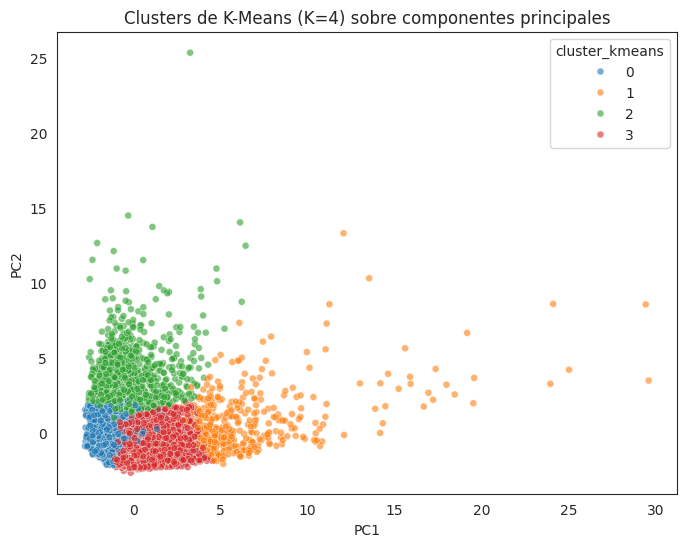

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.6,
    s=25
)
plt.title(f"Clusters de K-Means (K={K_ELEGIDO}) sobre componentes principales")
plt.show()


### Pipeline final: todo integrado en un solo objeto

Hasta ahora aplicamos cada paso por separado: primero el pipeline de preprocesamiento
(`SimpleImputer` + `StandardScaler`), despues el PCA, y despues K-Means. Eso esta bien para
explorar y entender cada paso, pero en un proyecto real se pide
integrar **todo el flujo en un solo Pipeline**, de principio a fin.

La estructura tipica de un Pipeline de clustering es:

1. **Imputacion**: manejo de valores nulos (`SimpleImputer`).
2. **Escalado**: normalizacion de los datos (`StandardScaler`).
3. **Transformacion**: reduccion de dimensionalidad (`PCA`, con `n_components=2`).
4. **Estimador final**: el algoritmo de aprendizaje no supervisado (`KMeans`).

La ventaja de encadenar todo esto en un solo `Pipeline` es que podemos llamar a `fit_predict`
una sola vez sobre los datos crudos, y Scikit-learn se encarga de pasar la salida de cada paso
como entrada del siguiente, en el orden correcto.

In [ ]:
# construir el pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pipeline_completo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
    ("kmeans", KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10))
])

pipeline_completo

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=2, random_state=42)),
                ('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

Observa que `K_ELEGIDO` es el mismo valor que definimos antes con el Metodo del Codo y el
Coeficiente de Silueta. El pipeline no reemplaza ese analisis: solo empaqueta la decision que ya
tomamos en un objeto reutilizable.

Ahora ajustamos el pipeline directamente sobre las features **crudas** (con nulos, sin
escalar). El pipeline se encarga de todo el preprocesamiento internamente.

In [ ]:
# entrenar y usar el pipeline

features = df.drop(columns=["Cust_id"])

# fit_predict ejecuta imputacion -> escalado -> PCA -> KMeans, todo en un solo paso
clusters_pipeline_completo = pipeline_completo.fit_predict(features)

df["cluster_pipeline_completo"] = clusters_pipeline_completo
df["cluster_pipeline_completo"].value_counts().sort_index()

,Cust_id,Balance,Balance_frequency,Purchases,Oneoff_purchases,Installments_purchases,Cash_advance,Purchases_frequency,Oneoff_purchases_frequency,Purchases_installments_frequency,Cash_advance_frequency,Cash_advance_trx,Purchases_trx,Credit_limit,Payments,Minimum_payments,Prc_full_payment,Tenure,cluster_kmeans,cluster_pipeline_completo
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0,0
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3,1
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,0,0
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,3,1
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6,3,1
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,3,1
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0,0


In [ ]:
# Accedemos al paso "pca" dentro del pipeline ya entrenado
pca_del_pipeline = pipeline_completo.named_steps["pca"]
print("Varianza explicada por el PCA del pipeline:", pca_del_pipeline.explained_variance_ratio_)

# Reconstruimos las componentes para graficar
componentes_pipeline = pipeline_completo[:-1].transform(features) # toma todos los pasos menos el último (todos sin el KMeans)
# seria equivalent de hacer eso:
#X = features
#X = pipeline_completo.named_steps["imputer"].transform(X)
#X = pipeline_completo.named_steps["scaler"].transform(X)
#X = pipeline_completo.named_steps["pca"].transform(X)
#componentes_pipeline = X

df_pipeline_pca = pd.DataFrame(componentes_pipeline, columns=["PC1", "PC2"])
df_pipeline_pca["cluster"] = clusters_pipeline_completo

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pipeline_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=25
)
plt.title("Clusters obtenidos con el Pipeline completo")
plt.show()

array([[-1.89034279, -1.06453472],
       [-1.10351293,  2.41558446],
       [ 1.22982169, -0.40982921],
       ...,
       [-0.50784309, -1.95817738],
       [-2.52656642, -0.6892285 ],
       [-0.79738446, -0.34601067]])

### Inspeccionar los pasos internos del pipeline

Una ventaja adicional de usar `Pipeline` es que podemos acceder a cada paso individual a
traves de `named_steps`, sin tener que romper el pipeline en pedazos. Por ejemplo, podemos
recuperar directamente las componentes principales que calculo el paso de PCA.

### Cierre de la sesion

Hoy avanzamos en:

- Aplicar PCA para reducir el dataset a 2 componentes principales y poder visualizarlo.
- Entrenar K-Means, justificando el numero de clusters con el Metodo del Codo y el Coeficiente
  de Silueta.
- Visualizar los clusters resultantes sobre el plano de componentes principales.
- Integrar todo en un pipeline profesional

**Para la proxima sesion (Sesion 3):** vamos a entrenar un segundo algoritmo (DBSCAN) para
comparar resultados, y vamos a hacer el perfilamiento final de los clusters: describir con
palabras que tipo de cliente representa cada grupo